# Daily Challenge: Binary Text Classification with the IMDB Dataset

Week 11, Day 3

Goal: classify movie reviews as **positive (1)** or **negative (0)**. The 50,000 reviews (25,000 for training, 25,000 for testing) are already encoded as sequences of integers, each integer being the index of a word among the **10,000 most frequent words**.

## 1. Preprocess the Data

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide TensorFlow C++ info logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)

num_words = 10_000  # keep the 10k most frequent tokens
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=num_words)

print("Train:", train_data.shape, train_labels.shape, "| Test:", test_data.shape, test_labels.shape)
print("First review (first 20 word indices):", train_data[0][:20])
print("Label of the first review:", train_labels[0])
print("Max word index:", max(max(seq) for seq in train_data))
print("Positive share - train: {:.1%} | test: {:.1%}".format(train_labels.mean(), test_labels.mean()))

TensorFlow: 2.21.0


       0/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  278528/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

 1540096/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

 7045120/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

13778944/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Train: (25000,) (25000,) | Test: (25000,) (25000,)
First review (first 20 word indices): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Label of the first review: 1
Max word index: 9999
Positive share - train: 50.0% | test: 50.0%


      0/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

 196608/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Review 0 - label 1 (positive):
this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilli ...

Review 1 - label 0 (negative):
big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is completely laughable the best is the end showdown with the cop and how he worked out who the killer is it's ju ...

count    25000.0
mean       239.0
std        176.0
min         11.0
25%        130.0
50%        178.0
75%        291.0
max    

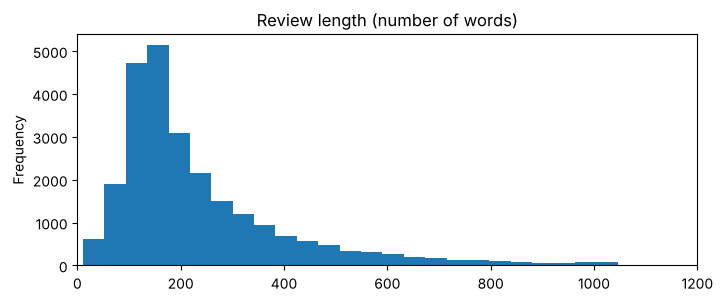

In [2]:
# Decode a review back to text (indices are offset by 3: 0 = padding, 1 = start, 2 = unknown word)
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
decode = lambda seq: " ".join(reverse_word_index.get(i, "?") for i in seq[1:])

for i in [0, 1]:
    print(f"Review {i} - label {train_labels[i]} ({'positive' if train_labels[i] else 'negative'}):")
    print(decode(train_data[i])[:400], "...\n")

lengths = pd.Series([len(s) for s in train_data])
print(lengths.describe().round(0))
lengths.plot(kind='hist', bins=60, figsize=(8, 3), title='Review length (number of words)')
plt.xlim(0, 1200); plt.show()

Each review is a list of integers of variable length (median about 180 words, some longer than 1,000). A neural network needs fixed-size tensors, so we **one-hot encode ("multi-hot")** each review as a 10,000-dimensional vector: position *i* is 1 if word *i* appears in the review, 0 otherwise. This "bag of words" representation loses the word order but keeps which words are used, which is already very informative for sentiment ("excellent", "worst", "boring"...).

In [3]:
def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension), dtype="float32")
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.  # set specific indices of results[i] to 1s
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

print("x_train:", x_train.shape, "| x_test:", x_test.shape)
print("First review vector:", x_train[0][:20], "... number of distinct words:", int(x_train[0].sum()))

x_train: (25000, 10000) | x_test: (25000, 10000)
First review vector: [0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.] ... number of distinct words: 120


In [4]:
# Split: 10,000 training reviews are set aside as a validation set; the 25,000 test reviews are kept for the end
x_val, partial_x_train = x_train[:10000], x_train[10000:]
y_val, partial_y_train = y_train[:10000], y_train[10000:]
print("Training:", partial_x_train.shape, "| Validation:", x_val.shape, "| Test:", x_test.shape)

Training: (15000, 10000) | Validation: (10000, 10000) | Test: (25000, 10000)


## 2. Build the Model

In [5]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(num_words,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

- **Two hidden Dense layers of 16 units with ReLU**: each layer computes `relu(W·x + b)`; 16 units is a small representation space, which limits the capacity of the network and therefore the risk of overfitting on 15,000 reviews.
- **Output: one unit with a sigmoid**, which gives a probability between 0 and 1 that the review is positive.
- **Loss: binary cross-entropy** (the right loss for a probability output on a binary problem), **optimizer: RMSprop**, **metric: accuracy** (meaningful here because the classes are exactly balanced: 50% positive).

## 3. Train the Model

In [6]:
history = model.fit(partial_x_train, partial_y_train,
                    epochs=20, batch_size=512,
                    validation_data=(x_val, y_val), verbose=2)

Epoch 1/20


30/30 - 3s - 96ms/step - accuracy: 0.7762 - loss: 0.5288 - val_accuracy: 0.8646 - val_loss: 0.3964


Epoch 2/20


30/30 - 0s - 12ms/step - accuracy: 0.8901 - loss: 0.3252 - val_accuracy: 0.8843 - val_loss: 0.3092


Epoch 3/20


...

30/30 - 0s - 12ms/step - accuracy: 0.9935 - loss: 0.0279 - val_accuracy: 0.8714 - val_loss: 0.5052


Epoch 19/20


30/30 - 0s - 11ms/step - accuracy: 0.9977 - loss: 0.0198 - val_accuracy: 0.8706 - val_loss: 0.5317


Epoch 20/20


30/30 - 1s - 24ms/step - accuracy: 0.9971 - loss: 0.0197 - val_accuracy: 0.8699 - val_loss: 0.5536


## 4. Evaluate the Model

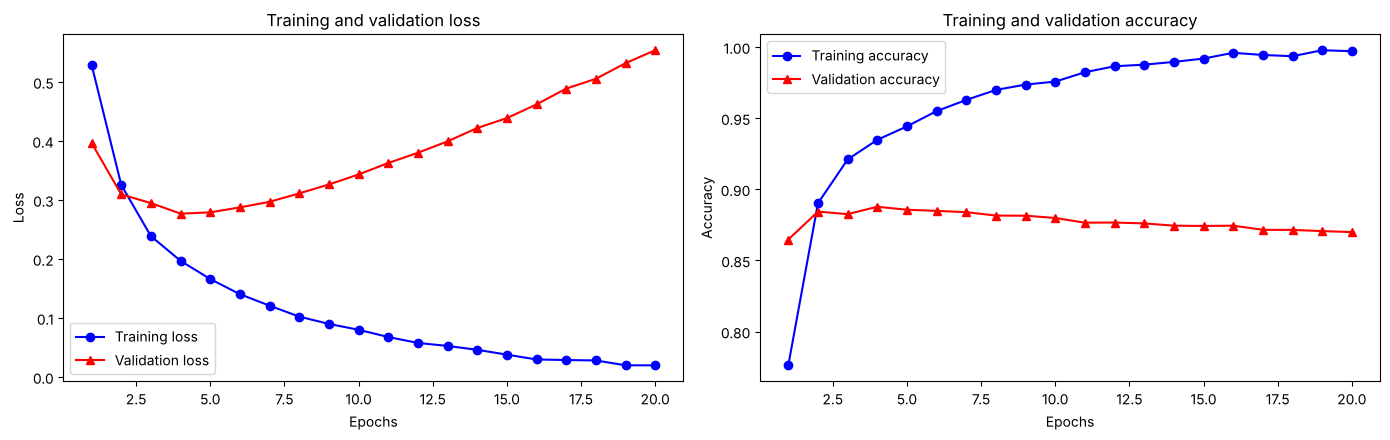

Lowest validation loss 0.2767 at epoch 4 (validation accuracy 0.8877)
Best validation accuracy 0.8877 at epoch 4
Epoch 20: training accuracy 0.9971, validation accuracy 0.8699, validation loss 0.5536


,accuracy,loss,val_accuracy,val_loss
1,0.7762,0.5288,0.8646,0.3964
2,0.8901,0.3252,0.8843,0.3092
3,0.9209,0.2385,0.8825,0.2947
4,0.9347,0.1967,0.8877,0.2767
5,0.9442,0.1659,0.8856,0.2789
6,0.9549,0.1402,0.8848,0.2874
7,0.9628,0.1208,0.8839,0.2968
8,0.9698,0.1022,0.8815,0.3111
9,0.9736,0.0899,0.8814,0.3262
10,0.9757,0.0800,0.8798,0.3431


In [7]:
h = pd.DataFrame(history.history)
h.index = h.index + 1
epochs = h.index

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(epochs, h['loss'], 'bo-', label='Training loss')
axes[0].plot(epochs, h['val_loss'], 'r^-', label='Validation loss')
axes[0].set_title('Training and validation loss'); axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].plot(epochs, h['accuracy'], 'bo-', label='Training accuracy')
axes[1].plot(epochs, h['val_accuracy'], 'r^-', label='Validation accuracy')
axes[1].set_title('Training and validation accuracy'); axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

best_epoch = int(h['val_loss'].idxmin())
print(f"Lowest validation loss {h['val_loss'].min():.4f} at epoch {best_epoch} "
      f"(validation accuracy {h.loc[best_epoch, 'val_accuracy']:.4f})")
print(f"Best validation accuracy {h['val_accuracy'].max():.4f} at epoch {int(h['val_accuracy'].idxmax())}")
print(f"Epoch 20: training accuracy {h.loc[20, 'accuracy']:.4f}, validation accuracy {h.loc[20, 'val_accuracy']:.4f}, "
      f"validation loss {h.loc[20, 'val_loss']:.4f}")
display(h.round(4))

**Detecting overfitting:**
- The **training loss** decreases at every epoch (0.53 → 0.02) and the **training accuracy** climbs to **99.7%**: the network ends up almost memorising the 15,000 training reviews.
- The **validation loss** reaches its **minimum at epoch 4 (0.277, validation accuracy 88.8%)** and then **increases steadily** (0.55 at epoch 20), while the validation accuracy slowly decreases (87.0% at epoch 20).
- After epoch 4, the curves **diverge**: the model keeps getting better on the training data but worse on new data. This is **overfitting**: it learns details specific to the training reviews (rare words, particular phrasings) that do not generalise.

So the optimal number of epochs is **4**. We now retrain a fresh model for 4 epochs, this time on all 25,000 training reviews (training + validation), and evaluate it once on the test set.

In [8]:
# Retrain a fresh model on all 25,000 training reviews with the optimal number of epochs
keras.utils.set_random_seed(SEED)
final_model = build_model()
final_model.fit(x_train, y_train, epochs=best_epoch, batch_size=512, verbose=2)

test_loss, test_acc = final_model.evaluate(x_test, y_test, verbose=0)
print(f"\nFinal model ({best_epoch} epochs) - test loss: {test_loss:.4f} | test accuracy: {test_acc:.4f}")

# For comparison: the overfitted model trained for 20 epochs
over_loss, over_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Model trained for 20 epochs       - test loss: {over_loss:.4f} | test accuracy: {over_acc:.4f}")

Epoch 1/4


49/49 - 1s - 19ms/step - accuracy: 0.8108 - loss: 0.4685


Epoch 2/4


49/49 - 0s - 8ms/step - accuracy: 0.9020 - loss: 0.2769


Epoch 3/4


49/49 - 0s - 8ms/step - accuracy: 0.9246 - loss: 0.2141


Epoch 4/4


49/49 - 0s - 8ms/step - accuracy: 0.9352 - loss: 0.1831



Final model (4 epochs) - test loss: 0.2899 | test accuracy: 0.8836


Model trained for 20 epochs       - test loss: 0.6036 | test accuracy: 0.8561


              precision    recall  f1-score   support

    negative     0.9047    0.8576    0.8805     12500
    positive     0.8646    0.9097    0.8866     12500

    accuracy                         0.8836     25000
   macro avg     0.8847    0.8836    0.8836     25000
weighted avg     0.8847    0.8836    0.8836     25000



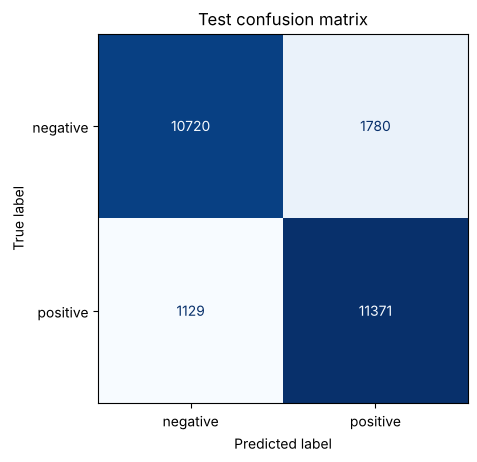


Most confident mistakes:
- true positive | P(positive) = 0.000: some spoilers included br br although many ? have called this film surreal the term fits poorly here to quote from ? surreal means br br fantastic or ? imagery one ? explain to the unimaginative how many ways a ? ten year old boy at large and seeking his fortune in the ? seat of a red ? could be fan...
- true negative | P(positive) = 1.000: los angeles 1976 indie film brat john carpenter fresh out of film school and with one film his class no budget spoof of 2001 called dark star under his belt finishes a gritty ? called assault on ? 13 the story of an almost deserted police station under siege by an unseen la gang it was a minor hit o...
- true negative | P(positive) = 1.000: before i took a job as a reviewer i never went to films like this and thus remained ? unaware that at the soul of the hollywood film lies a deeply woman hating spirit that ? on putting its knocking little knees on the silver screen for all to either

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

test_prob = final_model.predict(x_test, verbose=0).ravel()
test_pred = (test_prob > 0.5).astype(int)
print(classification_report(y_test, test_pred, target_names=['negative', 'positive'], digits=4))
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred), display_labels=['negative', 'positive']).plot(cmap='Blues', colorbar=False)
plt.title('Test confusion matrix'); plt.show()

# Examples: most confident correct predictions and the most confident mistakes
for title, idx in [("Most confident mistakes", np.argsort(-np.abs(test_prob - 0.5) * (test_pred != y_test))[:3])]:
    print(f"\n{title}:")
    for k in idx:
        print(f"- true {'positive' if y_test[k] else 'negative'} | P(positive) = {test_prob[k]:.3f}: {decode(test_data[k])[:300]}...")

## Bonus: a 1D Convolutional Network on the word sequences

The title of the challenge mentions a CNN. The bag-of-words model above ignores the order of the words; a **1D CNN** works on the sequence itself: an `Embedding` layer turns each word into a dense vector, and `Conv1D` filters slide over windows of 5 consecutive words to detect local patterns such as "not good at all" or "one of the best". We use the same train / validation split and compare on the test set.

In [10]:
maxlen = 400
seq_train = keras.utils.pad_sequences(train_data, maxlen=maxlen)
seq_test = keras.utils.pad_sequences(test_data, maxlen=maxlen)
seq_val, seq_partial = seq_train[:10000], seq_train[10000:]

keras.utils.set_random_seed(SEED)
cnn = keras.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(num_words, 64),
    layers.Dropout(0.3),
    layers.Conv1D(64, 5, activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])
cnn.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
cnn_hist = cnn.fit(seq_partial, y_train[10000:], epochs=10, batch_size=512, validation_data=(seq_val, y_val), verbose=2,
                   callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)])
cnn_loss, cnn_acc = cnn.evaluate(seq_test, y_test, verbose=0)
print(f"\n1D CNN - test loss: {cnn_loss:.4f} | test accuracy: {cnn_acc:.4f}")

Epoch 1/10


30/30 - 7s - 233ms/step - accuracy: 0.5105 - loss: 0.6925 - val_accuracy: 0.4969 - val_loss: 0.6899


Epoch 2/10


30/30 - 6s - 192ms/step - accuracy: 0.6071 - loss: 0.6724 - val_accuracy: 0.6914 - val_loss: 0.6356


Epoch 3/10


...

Epoch 9/10


30/30 - 6s - 215ms/step - accuracy: 0.8725 - loss: 0.3179 - val_accuracy: 0.8562 - val_loss: 0.3348


Epoch 10/10


30/30 - 6s - 205ms/step - accuracy: 0.8870 - loss: 0.2873 - val_accuracy: 0.8610 - val_loss: 0.3208



1D CNN - test loss: 0.3180 | test accuracy: 0.8626


In [11]:
summary = pd.DataFrame({
    'test accuracy': [over_acc, test_acc, cnn_acc],
    'test loss': [over_loss, test_loss, cnn_loss],
    'parameters': [model.count_params(), final_model.count_params(), cnn.count_params()],
}, index=['Dense 16-16, 20 epochs (overfitted)', f'Dense 16-16, {best_epoch} epochs (final)', 'Bonus: 1D CNN'])
display(summary.style.format({'test accuracy': '{:.4f}', 'test loss': '{:.4f}', 'parameters': '{:,}'}))

,test accuracy,test loss,parameters
"Dense 16-16, 20 epochs (overfitted)",0.8561,0.6036,"160,305"
"Dense 16-16, 4 epochs (final)",0.8836,0.2899,"160,305"
Bonus: 1D CNN,0.8626,0.3180,"662,657"


## 5. Analyze Results

| Model | Test accuracy | Test loss |
|---|---|---|
| Dense 16-16, trained 20 epochs (overfitted) | 0.8561 | 0.6036 |
| **Dense 16-16, retrained 4 epochs (final model)** | **0.8836** | **0.2899** |
| Bonus: 1D CNN (Embedding + Conv1D), 10 epochs | 0.8626 | 0.3180 |

- **Final result: the model classifies the test reviews with 88.4% accuracy and a test loss of 0.290.** Precision and recall are balanced between the two classes (F1 = 0.88 for negative and 0.89 for positive reviews); the model is slightly more likely to call a negative review positive (recall 85.8% for negative vs 91.0% for positive).
- **Training vs validation:** during the 20-epoch run, the training accuracy reached 99.7% but the validation accuracy peaked at 88.8% (epoch 4) and then dropped to 87.0%, while the validation loss doubled. Stopping at the right epoch is therefore essential: the model trained for 20 epochs is **2.8 points worse** on the test set and its loss is twice as high, because it is over-confident on its mistakes.
- The test accuracy of the final model (88.4%) is close to the best validation accuracy (88.8%), which confirms that the validation set gave a reliable estimate of the performance on new data.
- **Remaining errors:** the most confident mistakes are long, nuanced reviews (irony, plot summaries, reviews that discuss what other people say about the film). A bag-of-words model only sees *which* words are present, not their order, so it cannot understand negations or sarcasm ("not bad at all", "I expected the worst").
- **Bonus CNN:** the 1D CNN reads the words in order with an embedding and convolution filters over 5-word windows. It reached 86.3% after 10 epochs and was **still improving** (its validation loss was still going down), so with more epochs or pre-trained word embeddings it would likely overtake the simple dense model. Sequence models (CNN, LSTM, Transformers) are the next step to capture word order and context.

## Conclusion

We preprocessed the IMDB reviews into multi-hot vectors, built a small feedforward network (two Dense layers with ReLU and a sigmoid output) trained with RMSprop and binary cross-entropy, and used a validation set to detect overfitting after 4 epochs. Retraining with this optimal number of epochs gives **88.4% accuracy on 25,000 unseen test reviews**. Visualising the training and validation curves was the key step to choose the training duration and avoid overfitting.